# Valuing Call option on Apple stock with the help of CRR and BS

In [138]:
import numpy as np
import yfinance as yf
import pandas as pd

In [139]:
data = yf.download("AAPL", start="2025-01-01", end="2025-12-31")

[*********************100%***********************]  1 of 1 completed


In [140]:
print(len(data))

249


In [141]:
print(data.head())

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-01-02  242.525162  247.746638  240.506192  247.577549  55740700
2025-01-03  242.037827  242.853364  240.575812  242.037827  40244100
2025-01-06  243.668915  245.986258  241.878691  242.982661  45045600
2025-01-07  240.894089  244.215939  240.038760  241.659894  40856000
2025-01-08  241.381424  242.385946  238.745827  240.605663  37628900


In [142]:
prices=data["Close"]
print(prices[10:20])

Ticker            AAPL
Date                  
2025-01-17  228.730499
2025-01-21  221.430389
2025-01-22  222.613922
2025-01-23  222.444855
2025-01-24  221.569641
2025-01-27  228.611176
2025-01-28  236.965530
2025-01-29  238.059540
2025-01-30  236.299149
2025-01-31  234.717804


In [143]:
log_returns=np.log(prices).diff()
print(log_returns[10:20])

Ticker          AAPL
Date                
2025-01-17  0.007507
2025-01-21 -0.032436
2025-01-22  0.005331
2025-01-23 -0.000760
2025-01-24 -0.003942
2025-01-27  0.031286
2025-01-28  0.035892
2025-01-29  0.004606
2025-01-30 -0.007422
2025-01-31 -0.006715


In [144]:
sigma=float(np.std(log_returns,axis=0)*np.sqrt(252))  #annual volatility
print(sigma)

0.3215949231426327


/var/folders/67/gnc936c17bncjlvn45vv4xp00000gn/T/ipykernel_11916/3437473229.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma=float(np.std(log_returns,axis=0)*np.sqrt(252))  #annual volatility


In [145]:
ticker=yf.Ticker("AAPL")
expiries=ticker.options
print(expiries)

('2026-05-04', '2026-05-06', '2026-05-08', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')


In [146]:
from datetime import datetime

today= datetime.today()

for exp in expiries:
    exp_date=datetime.strptime(exp, "%Y-%m-%d")
    days=(exp_date - today).days
    print(exp, "->", days, "days")

2026-05-04 -> 1 days
2026-05-06 -> 3 days
2026-05-08 -> 5 days
2026-05-15 -> 12 days
2026-05-22 -> 19 days
2026-05-29 -> 26 days
2026-06-05 -> 33 days
2026-06-18 -> 46 days
2026-07-17 -> 75 days
2026-08-21 -> 110 days
2026-09-18 -> 138 days
2026-10-16 -> 166 days
2026-11-20 -> 201 days
2026-12-18 -> 229 days
2027-01-15 -> 257 days
2027-03-19 -> 320 days
2027-06-17 -> 410 days
2027-12-17 -> 593 days
2028-01-21 -> 628 days
2028-03-17 -> 684 days
2028-12-15 -> 957 days


In [147]:
expiry=expiries[11]
print(expiry)

2026-10-16


In [148]:
print(type(expiry))

<class 'str'>


In [149]:
expiry=datetime.strptime(expiry, "%Y-%m-%d")
print(type(expiry))

<class 'datetime.datetime'>


In [150]:
DTM=(expiry-today).days
T=DTM/365
print("Days to maturity:", DTM)
print("T:", T)

Days to maturity: 166
T: 0.4547945205479452


In [151]:
expiry=expiry.strftime("%Y-%m-%d")
print(type(expiry))

<class 'str'>


In [152]:
chain=ticker.option_chain(expiry)
calls=chain.calls
puts=chain.puts

#print(calls)

In [153]:
S0=ticker.history(period="1d")["Close"].iloc[-1]
print(S0)

280.1400146484375


In [154]:
K=280    # i have selected this just personally after printing all the calls in two steps back.
option=calls[calls["strike"] == K].iloc[0]
print(option)

contractSymbol             AAPL261016C00280000
lastTradeDate        2026-05-01 19:28:36+00:00
strike                                   280.0
lastPrice                                22.15
bid                                      21.75
ask                                       22.0
change                                3.299999
percentChange                        17.506626
volume                                   240.0
openInterest                              1200
impliedVolatility                      0.28968
inTheMoney                                True
contractSize                           REGULAR
currency                                   USD
Name: 27, dtype: object


In [155]:
market_price=option["lastPrice"]
print(market_price)

22.15


In [156]:
print(S0)
print(type(S0))
print(type(K))
K=float(K)

280.1400146484375
<class 'numpy.float64'>
<class 'int'>


In [187]:
def CRR(r, sigma,T,K,S0,M,option="call"):
    delta_T=T/M
    u = np.exp(sigma * np.sqrt(delta_T))
    d = np.exp(-sigma * np.sqrt(delta_T))
    q = (np.exp(r*delta_T) - d) / (u - d)

    S=np.zeros((M+1,M+1))
    S[0,0]=S0
    for i in range(1,M+1):
        for j in range(0,i+1):
            S[j,i]=S0*(u**j)*(d**(i-j))


    V=np.zeros((M+1,M+1))
    if option == "call":
        V[:,M]= np.maximum(S[:,M]-K,0)

    else:
        V[:,M]=np.maximum(K-S[:,M],0)


    for i in range(M-1,-1,-1):
        for j in range(0,i+1):
            V[j,i]=np.exp(-r*delta_T)*(q*V[j+1,i+1]+(1-q)*V[j,i+1])

    return V[0,0]
    

In [188]:
Model_Price = CRR(0.03, sigma,T,K,S0,100,option="call")
print(Model_Price)

25.984362336242686


In [189]:
print(market_price)

22.15


### Calculating implied volatility to calibrate model price with market price

In [190]:
def implied_volatility(S0, K, T, r, M, market_price, option="call"):
    
    low, high = 0.001, 2.0  # 0.1% to 200%

    for i in range(50):
        mid = (low + high) / 2
        
        price = CRR(r, mid, T, K, S0, M, option)
        
        if price > market_price:
            high = mid
        else:
            low = mid

    return (low + high) / 2

In [191]:
r=0.03
M=100
iv = implied_volatility(S0, K, T, r, M, market_price, "call")
print("Implied Volatility:", iv)

Implied Volatility: 0.26984357304267426


In [192]:
# hence the model is calibrated with the market price

In [193]:
model_price_iv = CRR(r, iv, T, K, S0, M, "call")
print(model_price_iv)

22.149999999999864


# Black Scholes Model

In [194]:
from scipy.stats import norm

In [195]:
def BS(S0, K, T, r, sigma, option="call"):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)


    if option=="call":
        return S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

    else:
        return K * np.exp(-r*T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

In [196]:
bs_price=BS(S0, K, T, 0.03, sigma, option="call")
print(bs_price)

26.03903557854258


In [197]:
print(market_price)

22.15


### Implied volatility with BS

In [198]:
def implied_volatility_BS(S0, K, T, r, market_price):
    low, high = 0.001, 2.0

    for _ in range(50):
        mid = (low + high) / 2
        price = BS(S0, K, T, r, mid,option="call")

        if price > market_price:
            high = mid
        else:
            low = mid

    return (low + high) / 2

In [199]:
IV_BS=implied_volatility_BS(S0, K, T, r, market_price)
print(IV_BS)

0.2692368354059367


#### Implied volatility inception into BS

In [200]:
print("BS Price using IV:", BS(S0, K, T, r, IV_BS,option="call"))
print("market_price:", market_price)

BS Price using IV: 22.14999999999995
market_price: 22.15


In [201]:
### just doing some additional stuff with changing M

In [202]:
print(type(S0))
print(type(K))
print(type(sigma))

<class 'numpy.float64'>
<class 'float'>
<class 'float'>


In [203]:
sigma=float(sigma)
print(type(sigma))

<class 'float'>


In [204]:
M_values=[2, 5, 10, 20, 30, 50, 75, 100, 200, 500]

crr_prices=[]

for x in M_values:
    price = CRR(0.03, sigma, T, K, S0, x, option="call")
    crr_prices.append(price)


In [205]:
for x, price in zip(M_values, crr_prices):
    print("M_values:", x, "->", "Price:", price)

M_values: 2 -> Price: 23.334872104605825
M_values: 5 -> Price: 27.245270677888172
M_values: 10 -> Price: 25.462609817385516
M_values: 20 -> Price: 25.75224058320154
M_values: 30 -> Price: 25.849219911722496
M_values: 50 -> Price: 25.926672847324504
M_values: 75 -> Price: 26.11808107835705
M_values: 100 -> Price: 25.984362336242686
M_values: 200 -> Price: 26.012790085568675
M_values: 500 -> Price: 26.029400239528606


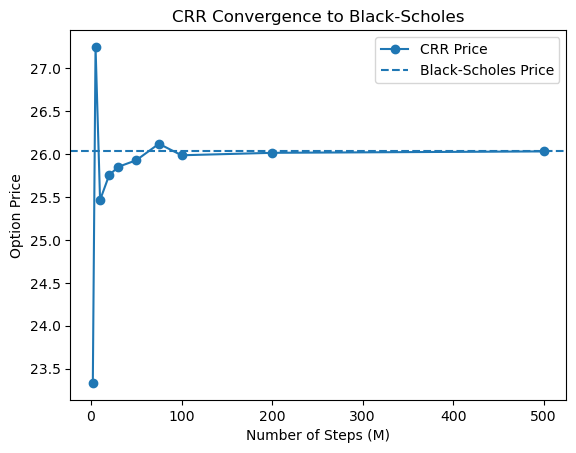

In [206]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(M_values, crr_prices, marker='o', label="CRR Price")
plt.axhline(y=bs_price, linestyle='--', label="Black-Scholes Price")

plt.xlabel("Number of Steps (M)")
plt.ylabel("Option Price")
plt.title("CRR Convergence to Black-Scholes")
plt.legend()

plt.show()

 ## Put Call Parity

In [208]:
put_price_CRR = CRR(r, sigma, T, K, S0, 100, option="put")
put_price_BS  = BS(S0, K, T, r, sigma, option="put")

print("Put Price CRR:", put_price_CRR)
print("Put Price BS: ", put_price_BS)

# Put-Call Parity check, using both CRR and BS
call_price_CRR = CRR(r, sigma, T, K, S0, 100, option="call")
call_price_BS  = BS(S0, K, T, r, sigma, option="call")

lhs_CRR = call_price_CRR - put_price_CRR
lhs_BS  = call_price_BS  - put_price_BS
rhs     = S0 - K * np.exp(-r * T)

print("\n--- Put-Call Parity ---")
print("CRR: C - P =", round(lhs_CRR, 4), " | S0 - Ke^-rT =", round(rhs, 4))
print("BS:  C - P =", round(lhs_BS,  4), " | S0 - Ke^-rT =", round(rhs, 4))

Put Price CRR: 22.05001718673162
Put Price BS:  22.104690429031095

--- Put-Call Parity ---
CRR: C - P = 3.9343  | S0 - Ke^-rT = 3.9343
BS:  C - P = 3.9343  | S0 - Ke^-rT = 3.9343


### now calculating the Greeks to detrmine the portfolio

In [217]:
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T)) #simply from BS Model
d2 = d1 - sigma*np.sqrt(T)

delta_call=norm.cdf(d1)
delta_put=norm.cdf(d1)-1

print("Delta Call:", round(delta_call, 4))
print("Delta Put:", round(delta_put, 4))

Delta Call: 0.5689
Delta Put: -0.4311


In [218]:
#this shows in order to replicate this option, i have to have 0.5689 shares of AAPl

In [219]:
gamma = norm.pdf(d1)/(S0*sigma*np.sqrt(T))
print("Gamma:", round(gamma, 4))

Gamma: 0.0065


In [220]:
# this shows that every one number change in stock would led the delta to change by 0.0065.
# so delta tells us the change in option value whereas the gamma tells us the change in delta with respect to change in stock.

In [221]:
vega = S0*norm.pdf(d1)*np.sqrt(T)
print("Vega:", round(vega, 4))

Vega: 74.2411


In [222]:
# this shows that with 100% increase in volatility, the option price will gain it's value by 74.2411.
# but in practice just one percent of the vega is used i.e., 0.01*vega = effect of change in volatility to option price 

## Replicating Portfolio

In [224]:
call_price = BS(S0, K, T, r, sigma, option="call")
put_price  = BS(S0, K, T, r, sigma, option="put")

# the underlying lines are to compute the bond position i.e., how much shall one in bonds invest

B_call = call_price - delta_call * S0
B_put  = put_price  - delta_put  * S0

print(f"\nCall Option:")
print(f"  Delta (shares to hold)  : {round(delta_call, 4)}")
print(f"  B     (bond position)   : {round(B_call, 4)}")
print(f"  Replicated Value        : {round(delta_call * S0 + B_call, 4)}")
print(f"  Actual Call Price       : {round(call_price, 4)}")

print(f"\nPut Option:")
print(f"  Delta (shares to hold)  : {round(delta_put, 4)}")
print(f"  B     (bond position)   : {round(B_put, 4)}")
print(f"  Replicated Value        : {round(delta_put * S0 + B_put, 4)}")
print(f"  Actual Put Price        : {round(put_price, 4)}")


Call Option:
  Delta (shares to hold)  : 0.5689
  B     (bond position)   : -133.3414
  Replicated Value        : 26.039
  Actual Call Price       : 26.039

Put Option:
  Delta (shares to hold)  : -0.4311
  B     (bond position)   : 142.8642
  Replicated Value        : 22.1047
  Actual Put Price        : 22.1047


# Volatility Smile

In [225]:
expiry = '2026-05-15'
chain = ticker.option_chain(expiry)

calls = chain.calls
puts  = chain.puts

print(calls.columns.tolist())
print(calls[['strike', 'lastPrice', 'impliedVolatility']].head(10))

['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']
   strike  lastPrice  impliedVolatility
0     5.0     254.00          14.480470
1    10.0     264.10          10.832034
2    15.0     246.63           0.000010
3    20.0     253.58           8.083989
4    25.0     248.63           7.306641
5    30.0     225.00           6.699220
6    35.0     238.65           6.203127
7    40.0     223.13           0.000010
8    45.0     221.66           2.875003
9    50.0     224.10           2.718753


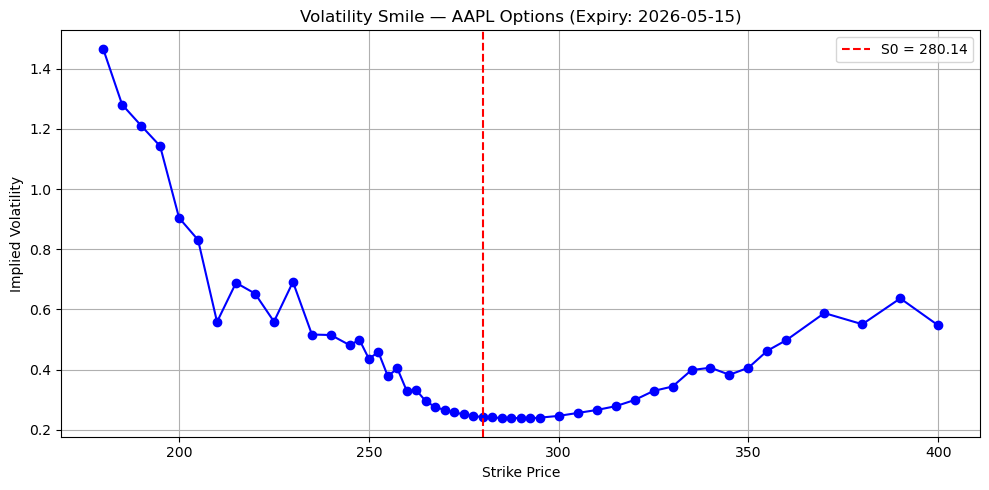

    strike  impliedVolatility
32   180.0           1.466311
33   185.0           1.280765
34   190.0           1.210941
35   195.0           1.143071
36   200.0           0.904298
37   205.0           0.831056
38   210.0           0.558598
39   215.0           0.688480
40   220.0           0.652836
41   225.0           0.559575
42   230.0           0.691409
43   235.0           0.516606
44   240.0           0.514897
45   245.0           0.480962
46   247.5           0.499517
47   250.0           0.436041
48   252.5           0.458257
49   255.0           0.377936
50   257.5           0.403815
51   260.0           0.328620
52   262.5           0.331306
53   265.0           0.294929
54   267.5           0.275642
55   270.0           0.265388
56   272.5           0.257820
57   275.0           0.251228
58   277.5           0.246834
59   280.0           0.241280
60   282.5           0.240974
61   285.0           0.239021
62   287.5           0.238289
63   290.0           0.239387
64   292.5

In [228]:
# Filter strikes near ATM — between 180 and 400
smile = calls[(calls['strike'] >= 180) & (calls['strike'] <= 400)].copy()

# Remove unreliable IV values (yfinance uses 0.000010 as placeholder for missing)
smile = smile[smile['impliedVolatility'] > 0.01]


plt.figure(figsize=(10, 5))
plt.plot(smile['strike'], smile['impliedVolatility'], marker='o', color='blue')
plt.axvline(x=S0, color='red', linestyle='--', label=f'S0 = {round(S0, 2)}')
plt.title('Volatility Smile — AAPL Options (Expiry: 2026-05-15)')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(smile[['strike', 'impliedVolatility']])

## Volatility Surface or Heatmap

In [229]:
selected_expiries = ['2026-05-15', '2026-06-18', '2026-07-17',   # selecting multiple expiries
                     '2026-09-18', '2026-12-18', '2027-03-19']


surface_data = {}

for expiry in selected_expiries:
    chain = ticker.option_chain(expiry)
    calls = chain.calls
    
    # filter strikes near ATM and remove bad IV same as last step
    filtered = calls[(calls['strike'] >= 180) & 
                     (calls['strike'] <= 400)].copy()
    filtered = filtered[filtered['impliedVolatility'] > 0.01]
    
    # store strike → IV mapping
    surface_data[expiry] = filtered.set_index('strike')['impliedVolatility']


surface_df = pd.DataFrame(surface_data)

print(surface_df.head(10))

        2026-05-15  2026-06-18  2026-07-17  2026-09-18  2026-12-18  2027-03-19
strike                                                                        
180.0     1.466311    0.669437    0.592778    0.533452    0.511602    0.503087
185.0     1.280765    0.648685    0.578740    0.514287    0.503484    0.492254
190.0     1.210941    0.619877    0.555424    0.552373    0.495488    0.479284
195.0     1.143071    0.584477    0.524785    0.514348    0.459173    0.462804
200.0     0.904298    0.593998    0.560490    0.490362    0.445623    0.443975
205.0     0.831056    0.567387    0.546147    0.468145    0.438665         NaN
210.0     0.558598    0.520513    0.515996    0.437139    0.421148    0.423834
215.0     0.688480    0.547368    0.492925    0.423773    0.410772         NaN
220.0     0.652836    0.529302    0.460821    0.409460    0.397070    0.410498
225.0     0.559575    0.488653    0.445074    0.396643    0.391913         NaN


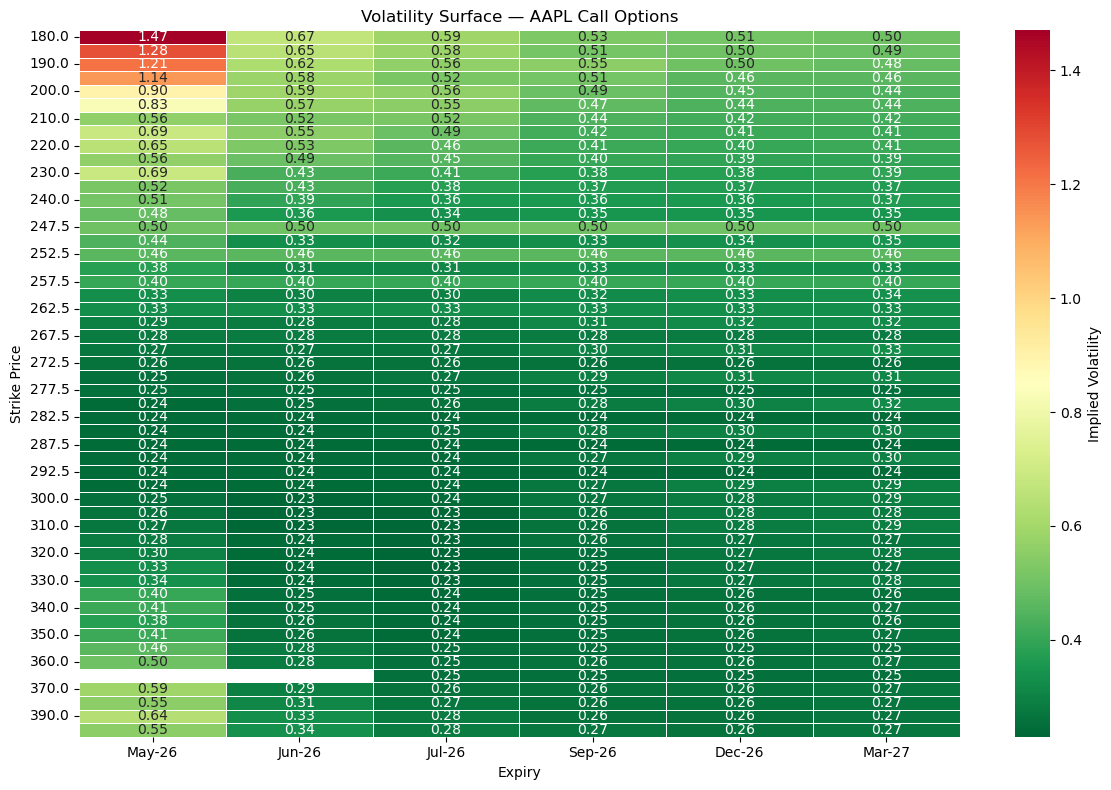

In [231]:
import seaborn as sns

# filling NaN with interpolation so that heatmap looks clean
surface_df = surface_df.interpolate(axis=1)

# rounding IV values for cleaner display
surface_df_rounded = surface_df.round(2)

# shorten expiry labels for cleaner axis
surface_df_rounded.columns = ['May-26', 'Jun-26', 'Jul-26', 
                               'Sep-26', 'Dec-26', 'Mar-27']

plt.figure(figsize=(12, 8))
sns.heatmap(surface_df_rounded, 
            cmap='RdYlGn_r',     ## red = high IV, green = low IV
            annot=True,          ## show values inside cells
            fmt='.2f',           # 2 decimal places
            linewidths=0.5,
            cbar_kws={'label': 'Implied Volatility'})

plt.title('Volatility Surface — AAPL Call Options')
plt.xlabel('Expiry')
plt.ylabel('Strike Price')
plt.tight_layout()
plt.show()